# RAG-Collapse · HotpotQA diverse-distractor sweep — results

Plots for the `diverse_synth` round-0 distractor experiment (oz03-hub setup): **qwen2.5-14b** answerer +
**qwen2.5-7b-docgen** per-round doc synthesis + **gpt-5-mini** round-0 distractors, native 2-gold/8-distractor
context, gold never corrupted. Sweep over 3 variants × fractions {0, 0.3, 0.5, 0.7}, 3 rounds, 7-question
eligible cohort, seed 42.

Each chart is its own figure (light theme) and is also saved to
`visualization_outputs/oz03_distractor_figures/`. **Data** lives in `oz03_distractor_sweep/` (gitignored);
repopulate with `scp -r unity:~/oz03_distractor_sweep <repo>/oz03_distractor_sweep`.

> Caveat: 7-question cohort — directional, not statistically significant. See `docs/hotpotqa_diverse_synth.html` §11.

In [1]:
import json, pathlib
import matplotlib.pyplot as plt

DATA = pathlib.Path("oz03_distractor_sweep")
FIGDIR = pathlib.Path("visualization_outputs/oz03_distractor_figures"); FIGDIR.mkdir(parents=True, exist_ok=True)
VARIANTS = ["search", "hybrid", "replace_one"]
VLABEL = {"search": "search (growing store)", "hybrid": "hybrid / replace-all", "replace_one": "replace_one"}
FRACS = ["0", "0.3", "0.5", "0.7"]; ROUNDS = [0, 1, 2]
DYN_F = "0.3"   # representative fraction for the per-round dynamics charts

# light palette (legible on white)
INK, MUTE, GRID, EDGE = "#1f2430", "#5b6472", "#e4e7ee", "#c6ccd8"
VC = {"search": "#7c3aed", "hybrid": "#0d9488", "replace_one": "#b45309"}  # violet / teal / amber
REF = "#dc2626"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "savefig.bbox": "tight", "savefig.dpi": 120, "figure.dpi": 120,
    "text.color": INK, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.edgecolor": EDGE, "xtick.color": MUTE, "ytick.color": MUTE,
    "grid.color": GRID, "axes.grid": True, "grid.alpha": 1.0, "font.size": 12,
    "axes.titlesize": 14, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 2.4, "lines.markersize": 7,
})
summ = {v: json.loads((DATA / f"sweep_summary_{v}.json").read_text())["fractions"] for v in VARIANTS}
def ser(v, f, m): return [summ[v][f][str(r)][m] for r in ROUNDS]
xf = [float(f) for f in FRACS]

def dynamics(metric, title, ylabel, ref1=False, ymax=None, fname=None):
    fig, ax = plt.subplots(figsize=(7.6, 4.9))
    for v in VARIANTS:
        ax.plot(ROUNDS, ser(v, DYN_F, metric), marker="o", color=VC[v], label=VLABEL[v])
    if ref1:
        ax.axhline(1.0, color=REF, ls=":", lw=1.3); ax.text(2, 1.04, "full collapse", color=REF, fontsize=9, ha="right")
    ax.set_title(f"{title}  ·  fraction {DYN_F}")
    ax.set_xlabel("round"); ax.set_ylabel(ylabel); ax.set_xticks(ROUNDS)
    ax.set_ylim(0 if not ref1 else 0.8, ymax)
    ax.legend()
    fig.tight_layout(); fig.savefig(FIGDIR / fname); plt.show()

def dose(metric, title, ylabel, ref1=False, ymax=None, fname=None):
    fig, ax = plt.subplots(figsize=(7.6, 4.9))
    for v in VARIANTS:
        ax.plot(xf, [summ[v][f]["2"][metric] for f in FRACS], marker="o", color=VC[v], label=VLABEL[v])
    if ref1:
        ax.axhline(1.0, color=REF, ls=":", lw=1.3); ax.text(0.7, 1.04, "full collapse", color=REF, fontsize=9, ha="right")
    ax.set_title(title)
    ax.set_xlabel("distractor fraction"); ax.set_ylabel(ylabel); ax.set_xticks(xf)
    ax.set_ylim(0.8 if ref1 else -0.03, ymax)
    ax.legend()
    fig.tight_layout(); fig.savefig(FIGDIR / fname); plt.show()

print("loaded", list(summ), "| figures ->", FIGDIR)


loaded ['search', 'hybrid', 'replace_one'] | figures -> visualization_outputs\oz03_distractor_figures


## 1 · Per-round dynamics (at fraction 0.3)

How each metric evolves over the 3 rounds, comparing the variants. This is where the variant-specific
behaviour shows: `search` locks in, `hybrid` washes out, `replace_one` is intermediate.

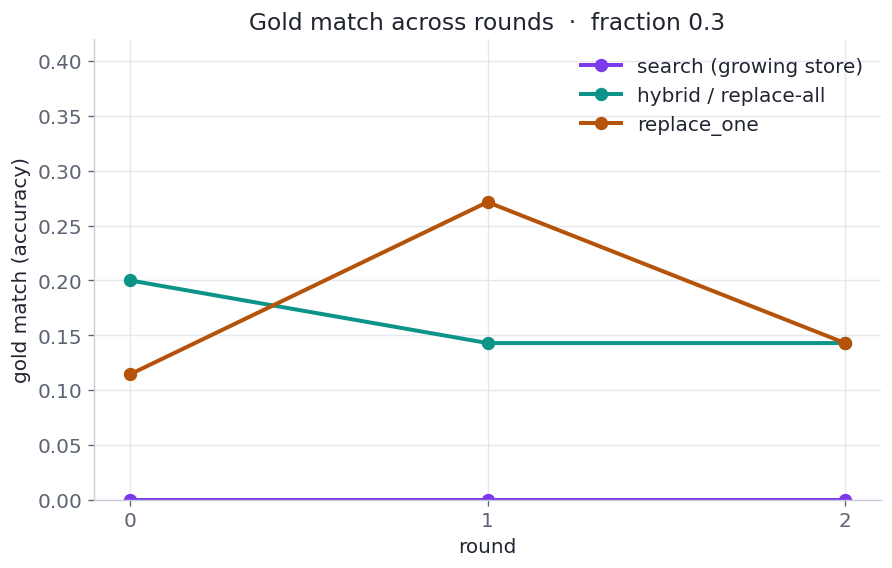

In [2]:
dynamics("gold_match", "Gold match across rounds", "gold match (accuracy)", ymax=0.42, fname="dyn_gold_match.png")

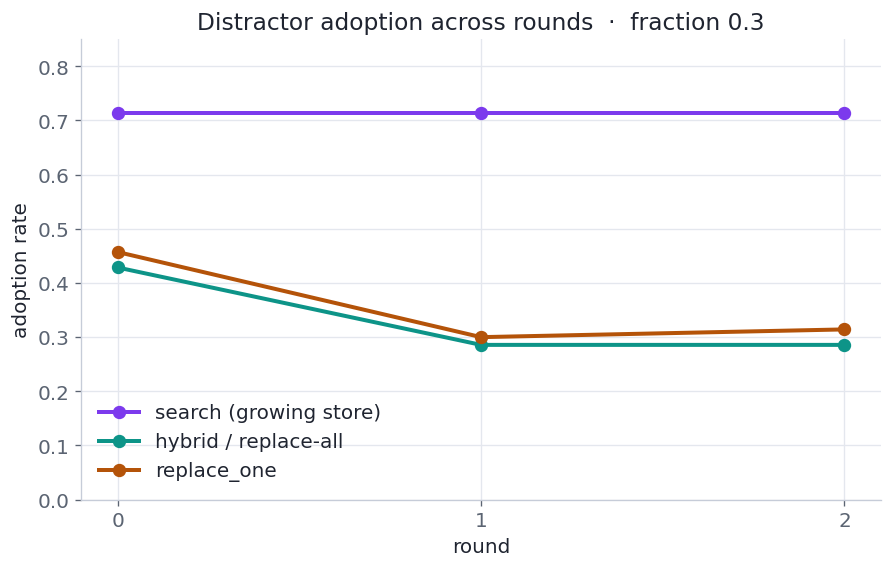

In [3]:
dynamics("distractor_adoption", "Distractor adoption across rounds", "adoption rate", ymax=0.85, fname="dyn_adoption.png")

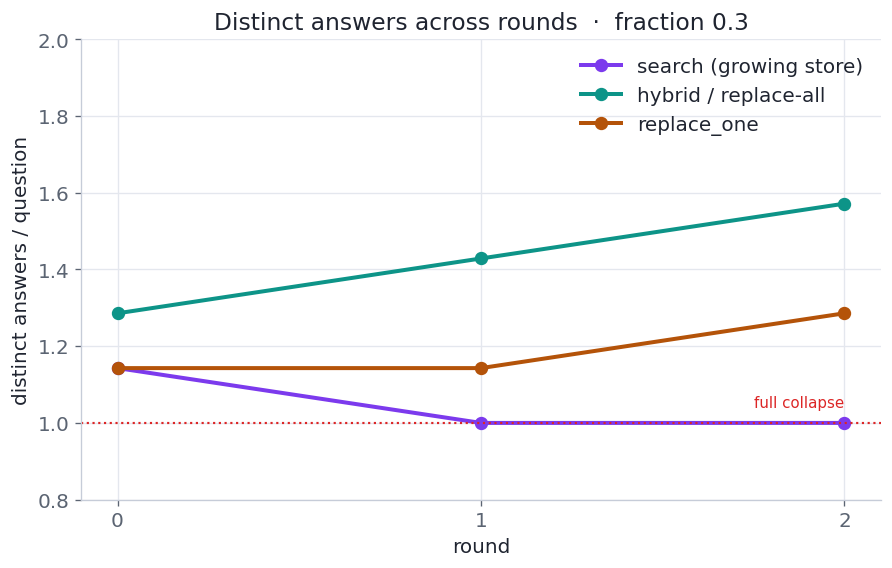

In [4]:
dynamics("distinct_answers", "Distinct answers across rounds", "distinct answers / question", ref1=True, ymax=2.0, fname="dyn_distinct.png")

## 2 · Dose-response (final round, r2)

How the final state depends on how many of the 8 non-gold slots are distractors.

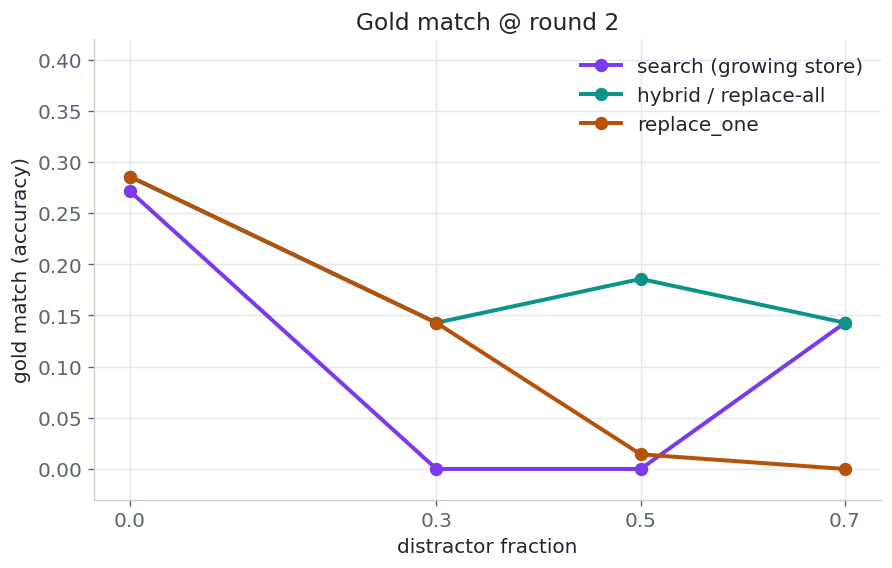

In [5]:
dose("gold_match", "Gold match @ round 2", "gold match (accuracy)", ymax=0.42, fname="dose_gold_match.png")

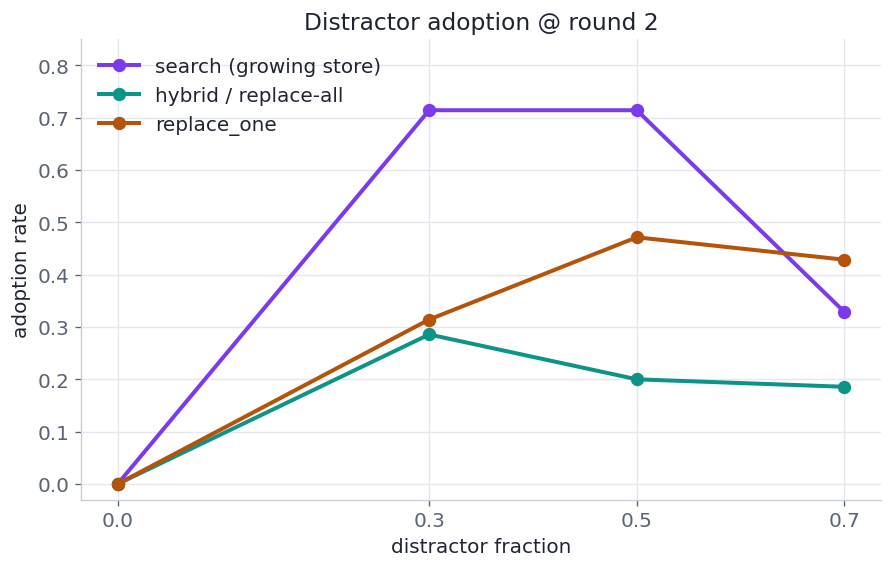

In [6]:
dose("distractor_adoption", "Distractor adoption @ round 2", "adoption rate", ymax=0.85, fname="dose_adoption.png")

## 3 · Concentration vs diffusion

Final-round `distinct_answers` vs fraction. Below 1.0-ward = collapse to one wrong answer (`search`);
above = the loop spreads answers out (`replace_one`/`hybrid`).

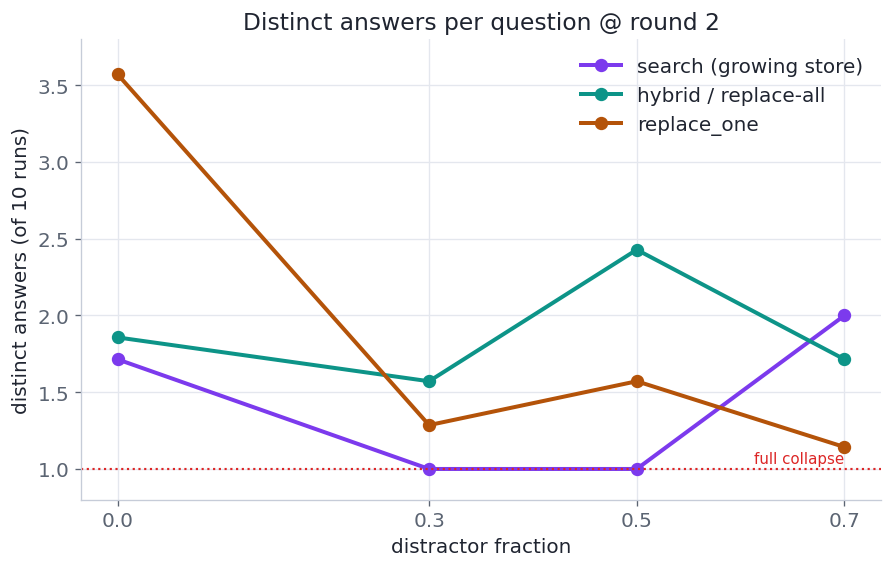

In [7]:
dose("distinct_answers", "Distinct answers per question @ round 2", "distinct answers (of 10 runs)", ref1=True, ymax=3.8, fname="conc_distinct.png")

## 4 · Example seeded distractors (qualitative)

Straight from a base experiment file: the distinct wrong answers gpt-5-mini planted, and what qwen answered.

In [8]:
bf = json.loads((DATA / "base_search_f0.7.json").read_text())
shown = 0
for q in bf["questions"]:
    dist = q.get("initial_distractor") or {}
    if not dist.get("eligible"):
        continue
    ents = [d["injected_entity"] for d in dist.get("distractors", []) if d.get("injected_entity")]
    answers = [(r.get("answer") or "").strip().replace("\n", " ")[:40] for r in q["iterations"][0]["runs"]]
    print("Q:", q["question_text"][:90])
    print("  gold:", dist.get("gold_answer"))
    print("  seeded distractors:", ", ".join(dict.fromkeys(ents)))
    print("  round-0 answers (10 runs):", answers)
    print()
    shown += 1
    if shown >= 3:
        break


Q: What government position was held by the woman who portrayed Corliss Archer in the film Ki
  gold: Chief of Protocol
  seeded distractors: United States Secretary of State, United States Senator, United States Ambassador to the United Nations, United States Attorney General, White House Press Secretary, Governor of California, United States Trade Representative
  round-0 answers (10 runs): ['United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N']

Q: What science fantasy young adult series, told in first person, has a set of companion book
  gold: Animorphs
  seeded distractors: The Hunger Games, Divergent,